In [1]:
import pandas as pd
df_ambiente = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_Ambient_data.csv')
df_sensores = pd.read_csv('/Users/pablocarcia/Library/CloudStorage/OneDrive-UNIR/TFM/DataSets/EDA/FSEC_Regional_Test_BaseLine_data.csv')

In [2]:
import pandas as pd
import numpy as np

def build_datetime(df):
    df = df.copy()

    df["DAY"] = df["DAY"].astype(str)
    df["YEAR"] = df["DAY"].str[:4].astype(int)
    df["DOY"] = df["DAY"].str[4:].astype(int)

    df["DATE"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["DOY"].astype(str).str.zfill(3),
        format="%Y%j"
    )

    df["DATETIME"] = pd.to_datetime(
        df["DATE"].astype(str) + " " + df["HOUR"].astype(str)
    )

    return df.drop(columns=["YEAR", "DOY", "DATE"])

In [3]:
baseline = build_datetime(df_ambiente)
baseline = baseline.replace(32767, np.nan)
baseline = baseline.drop(columns=["Unnamed: 0"], errors="ignore")
baseline = baseline.drop_duplicates()

In [4]:
ambiental = build_datetime(df_sensores)
ambiental = ambiental.replace(32767, np.nan)
ambiental = ambiental.drop(columns=["Unnamed: 0"], errors="ignore")
ambiental = ambiental.drop_duplicates()

In [5]:
df = pd.merge(
    baseline,
    ambiental,
    on=["DAY", "HOUR", "DATETIME"],
    how="inner",
    suffixes=("_elec", "_amb")
)

df = df.sort_values("DATETIME")
df = df.set_index("DATETIME")

df = df[(df['DAY'] >= "2018001") & (df['DAY'] < "2024001")]

In [6]:
df_day = df[df["GHRADA"] > 100].copy()
display(df_day)

,DAY,HOUR,GHRADA,DIRRAA,DIFRAA,PMBARA,WSMEAN,WDIREA,WDIRST,WSMSST,...,REC2RE,LAMBTA,POAIR1,ICP1JT,ICP2JT,ICP3JT,ICP4JT,ICP5JT,ICP6JT,ICP7JT
DATETIME,,,,,,,,,,,,,,,,,,,,,
2018-01-01 08:29:00,2018001,08:29:00,102.1,0.9,108.3,1019.6,0.00,0.0,0.00,0.00,...,0.00,15.69,98.3,22.35,23.23,0.0,0.0,21.39,18.49,19.02
2018-01-01 08:30:00,2018001,08:30:00,109.2,0.9,115.9,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.71,105.7,22.41,23.27,0.0,0.0,21.46,18.55,19.08
2018-01-01 08:31:00,2018001,08:31:00,112.5,0.9,119.8,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.82,110.7,22.45,23.34,0.0,0.0,21.52,18.62,19.11
2018-01-01 08:32:00,2018001,08:32:00,111.3,0.9,119.2,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.92,111.6,22.49,23.45,0.0,0.0,21.57,18.67,19.14
2018-01-01 08:33:00,2018001,08:33:00,109.6,0.9,117.4,1019.6,0.00,0.0,0.00,0.00,...,0.01,15.91,111.1,22.57,23.60,0.0,0.0,21.58,18.74,19.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 16:23:00,2023365,16:23:00,186.3,429.7,97.3,1022.4,1.52,241.0,19.08,0.63,...,0.02,137.44,354.8,26.88,27.37,0.0,0.0,25.55,22.87,23.74
2023-12-31 16:24:00,2023365,16:24:00,211.5,527.8,100.6,1022.4,0.86,234.0,16.97,0.72,...,0.02,138.17,380.6,26.90,27.36,0.0,0.0,25.53,22.84,23.72
2023-12-31 16:25:00,2023365,16:25:00,179.5,421.7,92.6,1022.4,1.67,232.1,21.97,0.45,...,0.02,138.67,348.6,26.93,27.35,0.0,0.0,25.48,22.83,23.69


In [7]:
missing_values_percentage = df.isnull().sum() / len(df) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))

REC1TE    47.960533
REC2TE    47.551727
DIRRAA    13.011372
MODT07     5.500057
MODT08     5.499962
            ...    
WSMSST     0.831051
WDIRST     0.831051
WDIREA     0.831051
WSMEAN     0.831051
PMBARA     0.831051
Length: 68, dtype: float64

In [8]:
df_day["hour"] = df_day.index.hour
df_day["minute"] = df_day.index.minute
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_day = df[df["GHRADA"] > 50].copy()

df_day["hour"] = df_day.index.hour
df_day["minute"] = df_day.index.minute
df_day["dayofyear"] = df_day.index.dayofyear
df_day["month"] = df_day.index.month

features_pred = [
    "GHRADA", "DIRRAA", "DIFRAA",
    "TMPCAV", "RHPCTA", "WSMEAN",
    "hour", "minute", "dayofyear", "month"
]

target = "S2WACA"

data_pred = df_day[features_pred + [target]].copy()
data_pred = data_pred.replace([np.inf, -np.inf], np.nan)
data_pred = data_pred.dropna()

train = data_pred[data_pred.index < "2022-01-01"].copy()

val = data_pred[
    (data_pred.index >= "2022-01-01") &
    (data_pred.index < "2023-01-01")
].copy()

test = data_pred[data_pred.index >= "2023-01-01"].copy()

train_clean = train.copy()

train_clean = train_clean[
    (train_clean["GHRADA"] > 75) &
    (train_clean["S2WACA"] > 20) &
    (train_clean["RHPCTA"].between(0, 100)) &
    (train_clean["TMPCAV"].between(-15, 65)) &
    (train_clean["WSMEAN"] >= 0)
].copy()

train_clean = train_clean[
    ~(
        (train_clean["GHRADA"] > 600) &
        (train_clean["S2WACA"] < 200)
    )
].copy()

lower_power_limit = train_clean["S2WACA"].quantile(0.0005)
upper_power_limit = train_clean["S2WACA"].quantile(0.9995)

train_clean = train_clean[
    train_clean["S2WACA"].between(lower_power_limit, upper_power_limit)
].copy()

print("Tamaño train original:", train.shape)
print("Tamaño train limpio:", train_clean.shape)
print(
    "Porcentaje conservado:",
    round(len(train_clean) / len(train) * 100, 2),
    "%"
)

X_train = train_clean[features_pred]
y_train = train_clean[target]

X_val = val[features_pred]
y_val = val[target]

X_test = test[features_pred]
y_test = test[target]

# Tamaño de cada conjunto
print("Train:", train.shape)
print("Validación:", val.shape)
print("Test:", test.shape)

# Número de registros
print("Registros train:", len(train))
print("Registros validación:", len(val))
print("Registros test:", len(test))

# Porcentaje sobre el total
total = len(train) + len(val) + len(test)

print("\nPorcentaje de registros:")
print("Train:", round(len(train) / total * 100, 2), "%")
print("Validación:", round(len(val) / total * 100, 2), "%")
print("Test:", round(len(test) / total * 100, 2), "%")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val = val.copy()
test = test.copy()

val["y_pred"] = rf_model.predict(X_val)
test["y_pred"] = rf_model.predict(X_test)


def regression_metrics(y_true, y_pred, name="Modelo"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"Resultados {name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2  : {r2:.4f}")

regression_metrics(val[target], val["y_pred"], "validación")
regression_metrics(test[target], test["y_pred"], "test")

val["residual"] = val[target] - val["y_pred"]
test["residual"] = test[target] - test["y_pred"]

val["abs_residual"] = val["residual"].abs()
test["abs_residual"] = test["residual"].abs()

val["relative_error"] = (
    val["abs_residual"] /
    val["y_pred"].abs().clip(lower=100)
)

test["relative_error"] = (
    test["abs_residual"] /
    test["y_pred"].abs().clip(lower=100)
)


threshold_abs = val["abs_residual"].quantile(0.995)
threshold_rel = val["relative_error"].quantile(0.995)

print("Umbral absoluto:", threshold_abs)
print("Umbral relativo:", threshold_rel)

test["anomaly_abs_residual"] = (
    test["abs_residual"] > threshold_abs
).astype(int)

test["anomaly_rf_residual"] = (
    (test["abs_residual"] > threshold_abs) &
    (test["relative_error"] > threshold_rel)
).astype(int)

test["anomaly_rf_soft"] = (
    (test["abs_residual"] > threshold_abs) |
    (test["relative_error"] > threshold_rel)
).astype(int)


print("Anomalías por residuo absoluto:")
print(test["anomaly_abs_residual"].value_counts(normalize=True) * 100)

print("\nAnomalías combinadas:")
print(test["anomaly_rf_residual"].value_counts(normalize=True) * 100)

print("\nAnomalías soft:")
print(test["anomaly_rf_soft"].value_counts(normalize=True) * 100)


df_day["y_pred_rf"] = np.nan
df_day["residual_rf"] = np.nan
df_day["abs_residual_rf"] = np.nan
df_day["relative_error_rf"] = np.nan
df_day["anomaly_rf_residual"] = np.nan
df_day["anomaly_rf_soft"] = np.nan

df_day.loc[test.index, "y_pred_rf"] = test["y_pred"]
df_day.loc[test.index, "residual_rf"] = test["residual"]
df_day.loc[test.index, "abs_residual_rf"] = test["abs_residual"]
df_day.loc[test.index, "relative_error_rf"] = test["relative_error"]
df_day.loc[test.index, "anomaly_rf_residual"] = test["anomaly_rf_residual"]
df_day.loc[test.index, "anomaly_rf_soft"] = test["anomaly_rf_soft"]

Tamaño train original: (760850, 11)
Tamaño train limpio: (585472, 11)
Porcentaje conservado: 76.95 %
Train: (760850, 11)
Validación: (97994, 11)
Test: (210507, 11)
Registros train: 760850
Registros validación: 97994
Registros test: 210507

Porcentaje de registros:
Train: 71.15 %
Validación: 9.16 %
Test: 19.69 %
Resultados validación
MAE : 110.53
RMSE: 153.14
R2  : 0.9563
Resultados test
MAE : 109.69
RMSE: 153.41
R2  : 0.9529
Umbral absoluto: 672.6694921584107
Umbral relativo: 1.1588996941357135
Anomalías por residuo absoluto:
anomaly_abs_residual
0    99.548234
1     0.451766
Name: proportion, dtype: float64

Anomalías combinadas:
anomaly_rf_residual
0    99.979573
1     0.020427
Name: proportion, dtype: float64

Anomalías soft:
anomaly_rf_soft
0    99.13067
1     0.86933
Name: proportion, dtype: float64


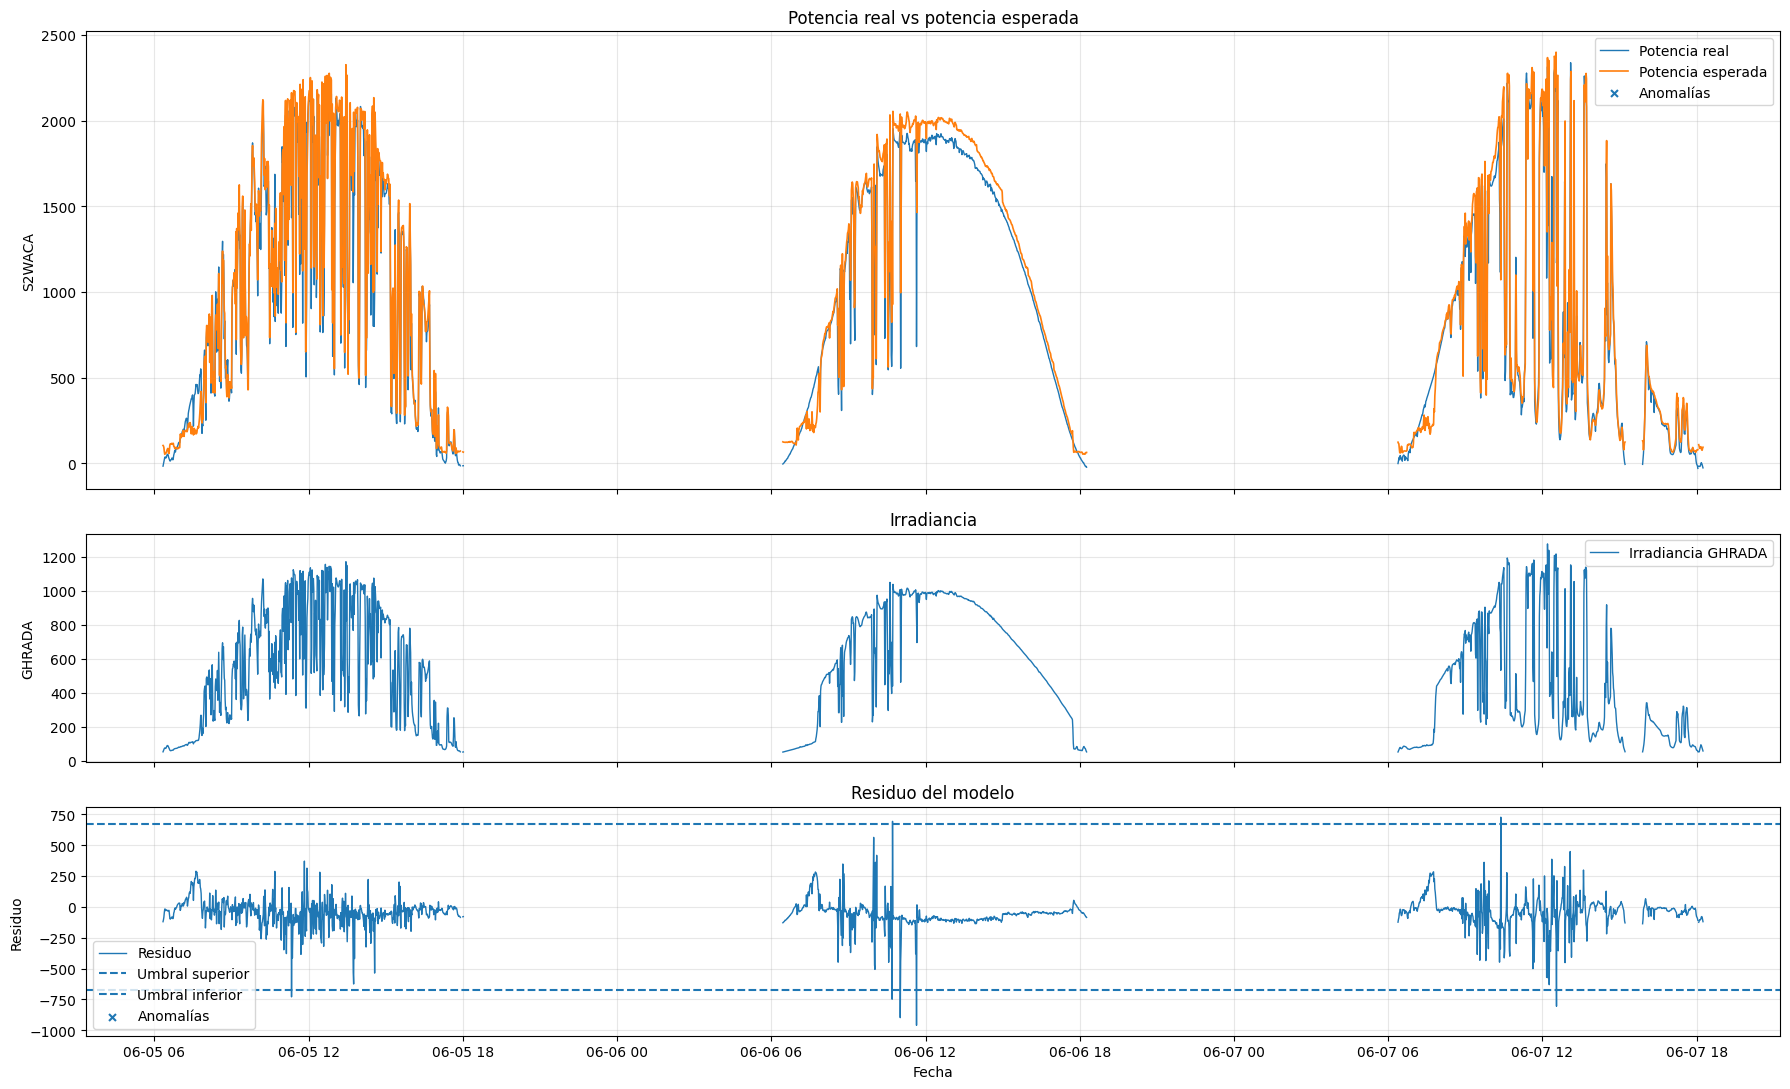

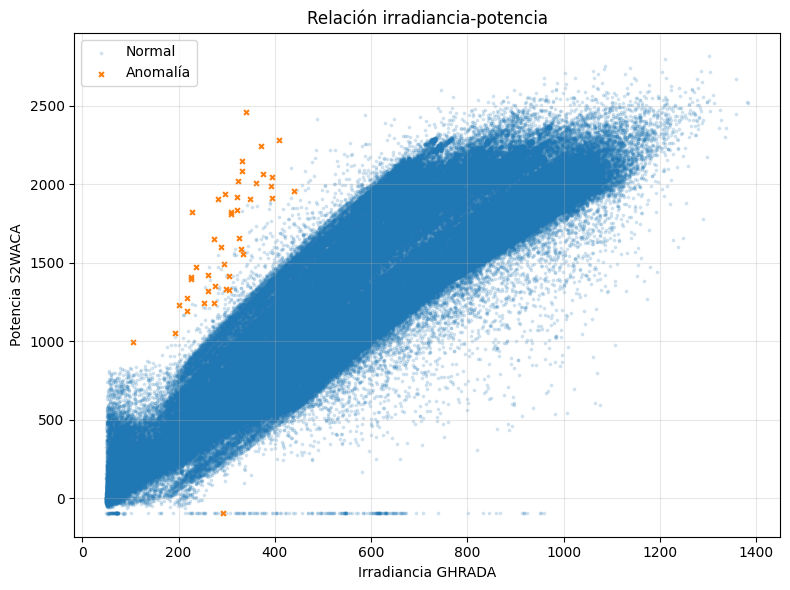

In [10]:
def plot_power_prediction_with_irradiance(
    df_result,
    threshold_abs,
    start=None,
    end=None,
    target_col="S2WACA",
    pred_col="y_pred",
    residual_col="residual",
    anomaly_col="anomaly_rf_residual",
    irradiance_col="GHRADA"
):
    data = df_result.copy()

    if start is not None or end is not None:
        data = data.loc[start:end].copy()

    data = data.asfreq("1min")

    anomalies = data[data[anomaly_col] == 1]

    fig, axes = plt.subplots(
        3, 1,
        figsize=(18, 11),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1, 1]}
    )

    axes[0].plot(
        data.index,
        data[target_col],
        label="Potencia real",
        linewidth=1
    )

    axes[0].plot(
        data.index,
        data[pred_col],
        label="Potencia esperada",
        linewidth=1.2
    )

    axes[0].scatter(
        anomalies.index,
        anomalies[target_col],
        marker="x",
        s=25,
        label="Anomalías"
    )

    axes[0].set_title("Potencia real vs potencia esperada")
    axes[0].set_ylabel("S2WACA")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        data.index,
        data[irradiance_col],
        label="Irradiancia GHRADA",
        linewidth=1
    )

    axes[1].set_title("Irradiancia")
    axes[1].set_ylabel("GHRADA")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(
        data.index,
        data[residual_col],
        label="Residuo",
        linewidth=1
    )

    axes[2].axhline(
        threshold_abs,
        linestyle="--",
        label="Umbral superior"
    )

    axes[2].axhline(
        -threshold_abs,
        linestyle="--",
        label="Umbral inferior"
    )

    axes[2].scatter(
        anomalies.index,
        anomalies[residual_col],
        marker="x",
        s=25,
        label="Anomalías"
    )

    axes[2].set_title("Residuo del modelo")
    axes[2].set_xlabel("Fecha")
    axes[2].set_ylabel("Residuo")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def plot_irradiance_power_scatter(
    df_result,
    anomaly_col="anomaly_rf_residual",
    irradiance_col="GHRADA",
    power_col="S2WACA"
):
    data = df_result[[irradiance_col, power_col, anomaly_col]].dropna().copy()

    normal = data[data[anomaly_col] == 0]
    anom = data[data[anomaly_col] == 1]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        normal[irradiance_col],
        normal[power_col],
        s=3,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anom[irradiance_col],
        anom[power_col],
        s=12,
        marker="x",
        label="Anomalía"
    )

    plt.xlabel("Irradiancia GHRADA")
    plt.ylabel("Potencia S2WACA")
    plt.title("Relación irradiancia-potencia")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_power_prediction_with_irradiance(
    test,
    threshold_abs=threshold_abs,
    start="2023-06-05",
    end="2023-06-07",
    target_col="S2WACA",
    pred_col="y_pred",
    residual_col="residual",
    anomaly_col="anomaly_rf_residual",
    irradiance_col="GHRADA"
)

plot_irradiance_power_scatter(
    test,
    anomaly_col="anomaly_rf_residual"
)

In [11]:
test["anomaly_level"] = "normal"

test.loc[test["anomaly_rf_soft"] == 1, "anomaly_level"] = "leve"
test.loc[test["anomaly_abs_residual"] == 1, "anomaly_level"] = "media"
test.loc[test["anomaly_rf_residual"] == 1, "anomaly_level"] = "alta"

In [12]:
test["anomaly_level"].value_counts(normalize=True) * 100

anomaly_level
normal    99.130670
media      0.431340
leve       0.417563
alta       0.020427
Name: proportion, dtype: float64

In [13]:
test["anom_zero_power_high_irr"] = (
    (test["GHRADA"] > 500) &
    (test["S2WACA"] < 300) &
    (test["anomaly_rf_soft"] == 1)
).astype(int)

test["anom_high_power_low_irr"] = (
    (test["GHRADA"] < 500) &
    (test["S2WACA"] > 1200) &
    (test["anomaly_rf_soft"] == 1)
).astype(int)

test["anom_large_underproduction"] = (
    (test["residual"] < -threshold_abs) &
    (test["anomaly_rf_soft"] == 1)
).astype(int)

test["anom_large_overproduction"] = (
    (test["residual"] > threshold_abs) &
    (test["anomaly_rf_soft"] == 1)
).astype(int)

In [14]:
anom_type_cols = [
    "anom_zero_power_high_irr",
    "anom_high_power_low_irr",
    "anom_large_underproduction",
    "anom_large_overproduction"
]

test[anom_type_cols].sum().sort_values(ascending=False)

anom_large_underproduction    809
anom_large_overproduction     142
anom_zero_power_high_irr      110
anom_high_power_low_irr       101
dtype: int64

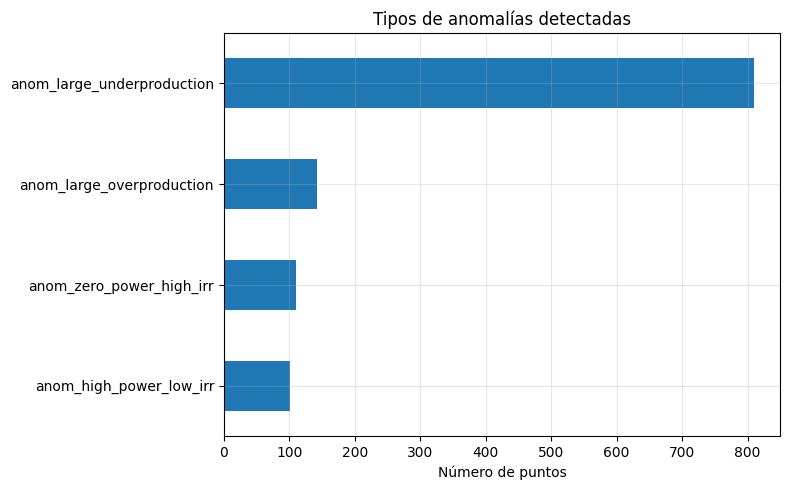

In [15]:
anom_counts = test[anom_type_cols].sum().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
anom_counts.plot(kind="barh")
plt.xlabel("Número de puntos")
plt.title("Tipos de anomalías detectadas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/z4/0f39p73148q9qzf1bl7k2vsr0000gn/T/ipykernel_18044/457429021.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_anomalies = test["anomaly_rf_soft"].resample("M").mean() * 100


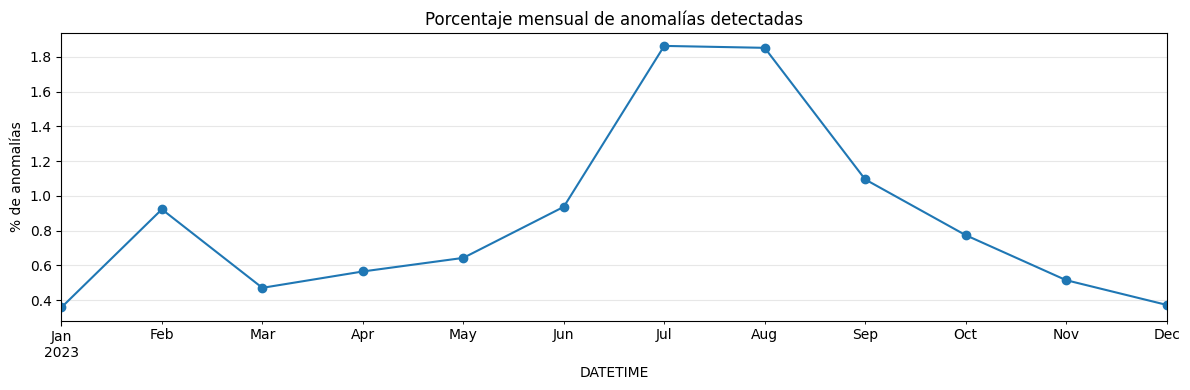

In [16]:
monthly_anomalies = test["anomaly_rf_soft"].resample("M").mean() * 100

plt.figure(figsize=(12, 4))
monthly_anomalies.plot(marker="o")
plt.ylabel("% de anomalías")
plt.title("Porcentaje mensual de anomalías detectadas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
test["anomaly_underproduction"] = (
    (test["residual"] < -threshold_abs) &
    (test["relative_error"] > threshold_rel)
).astype(int)

test["anomaly_overproduction"] = (
    (test["residual"] > threshold_abs) &
    (test["relative_error"] > threshold_rel)
).astype(int)

summary = pd.DataFrame({
    "n_puntos": [
        len(test),
        test["anomaly_rf_soft"].sum(),
        test["anomaly_rf_residual"].sum(),
        test["anomaly_underproduction"].sum(),
        test["anomaly_overproduction"].sum()
    ],
    "porcentaje": [
        100,
        test["anomaly_rf_soft"].mean() * 100,
        test["anomaly_rf_residual"].mean() * 100,
        test["anomaly_underproduction"].mean() * 100,
        test["anomaly_overproduction"].mean() * 100
    ]
}, index=[
    "Total",
    "Anomalías leves",
    "Anomalías fuertes",
    "Subproducción",
    "Sobreproducción"
])

summary

,n_puntos,porcentaje
Total,210507,100.000000
Anomalías leves,1830,0.869330
Anomalías fuertes,43,0.020427
Subproducción,1,0.000475
Sobreproducción,42,0.019952


In [18]:
import matplotlib.pyplot as plt

def plot_abs_error_vs_prediction(
    df_result,
    threshold_abs,
    pred_col="y_pred",
    abs_residual_col="abs_residual",
    anomaly_col="anomaly_rf_soft"
):
    data = df_result[
        [pred_col, abs_residual_col, anomaly_col]
    ].dropna().copy()

    normal = data[data[anomaly_col] == 0]
    anom = data[data[anomaly_col] == 1]

    plt.figure(figsize=(10, 6))

    plt.scatter(
        normal[pred_col],
        normal[abs_residual_col],
        s=3,
        alpha=0.15,
        label="Normal"
    )

    plt.scatter(
        anom[pred_col],
        anom[abs_residual_col],
        s=18,
        marker="x",
        label="Anomalía"
    )

    plt.axhline(
        threshold_abs,
        linestyle="--",
        label=f"Umbral absoluto = {threshold_abs:.2f}"
    )

    plt.xlabel("Potencia esperada")
    plt.ylabel("Error absoluto")
    plt.title("Error absoluto frente a potencia esperada")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

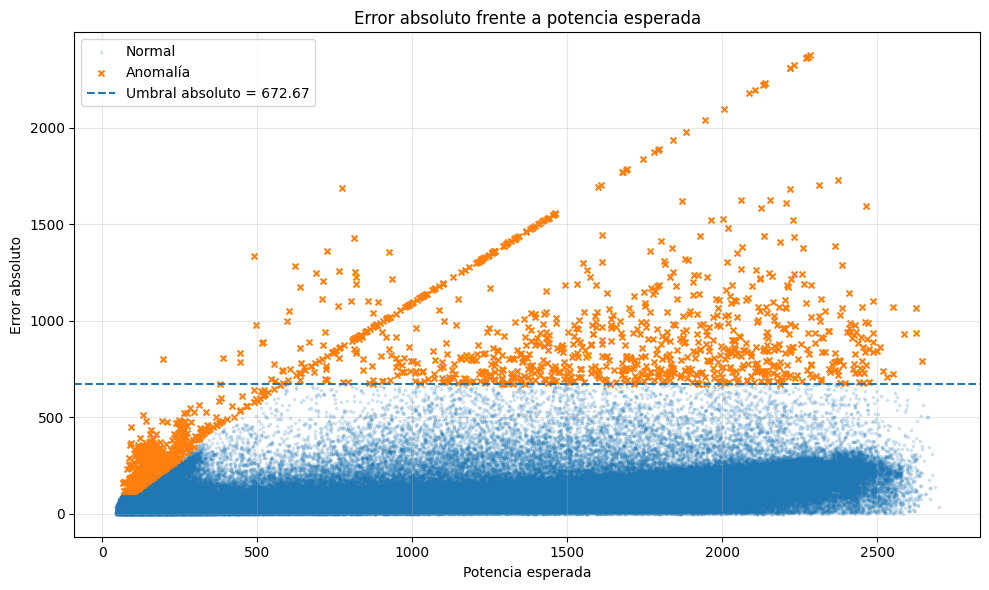

In [19]:
plot_abs_error_vs_prediction(
    test,
    threshold_abs=threshold_abs
)

In [20]:
import matplotlib.pyplot as plt

def plot_residual_distribution(
    df_result,
    threshold_abs,
    residual_col="residual"
):
    data = df_result[residual_col].dropna()

    plt.figure(figsize=(10, 5))

    plt.hist(
        data,
        bins=100,
        alpha=0.8
    )

    plt.axvline(
        threshold_abs,
        linestyle="--",
        label="Umbral superior"
    )

    plt.axvline(
        -threshold_abs,
        linestyle="--",
        label="Umbral inferior"
    )

    plt.xlabel("Residuo: potencia real - potencia esperada")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de residuos del modelo")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

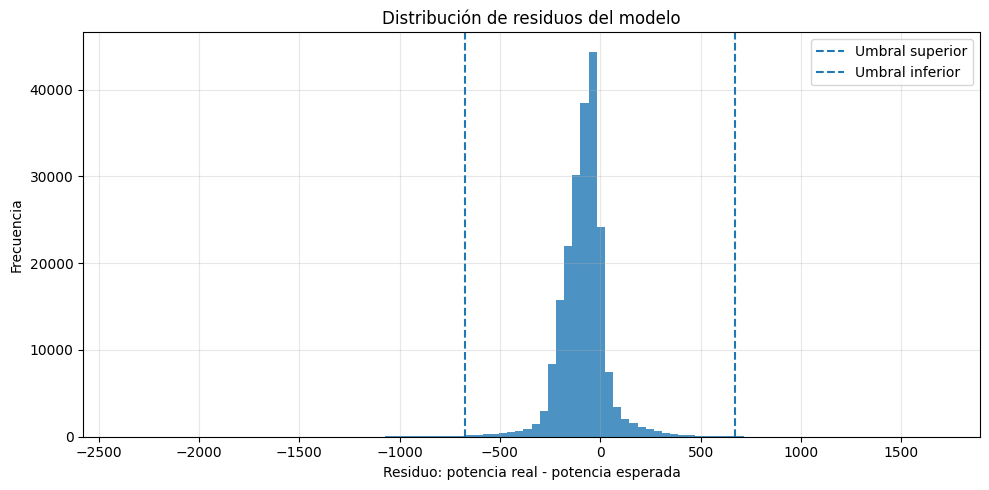

In [21]:
plot_residual_distribution(
    test,
    threshold_abs=threshold_abs
)